<a href="https://colab.research.google.com/github/emzu/futureIDF/blob/main/01)Process_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initialization

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git config --global user.email "ezuetell@andrew.cmu.edu"
!git config --global user.name "emzu"

try:
    !git clone "https://github.com/emzu/futureIDF"
except:
    print("Already cloned")

%cd /content/futureIDF
!git pull

# Load Packages
!pip install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'futureIDF' already exists and is not an empty directory.
/content/futureIDF
Already up to date.


In [2]:
!git pull

# Import modules
import sys
import importlib
# Ensure workspace root is on sys.path so the local `modules` package can be imported
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
import warnings
warnings.filterwarnings('ignore')

from modules import config, data_io, timeseries, plotting, process_rp, geospatial
importlib.reload(timeseries)
importlib.reload(data_io)
importlib.reload(process_rp)
importlib.reload(geospatial)

Already up to date.


<module 'modules.geospatial' from '/content/futureIDF/modules/geospatial.py'>

# Download and Process Raw Data (If needed)

In [ ]:
from pathlib import Path
import wget


loca2_directory = "https://cirrus.ucsd.edu/~pierce/LOCA2/CONUS_regions_split"

for model in config.MODELS_LOCA2[:1]:
  for scen in ['historical']:
    for ensemble in range(1,10):
      for time_period in ['1950-2014']:
        ########## DOWNLOAD DATA ##########
        region = "n_east"
        directory = f"{loca2_directory}/{model}/{region}/0p0625deg/r{ensemble}i1p1f1/{scen}/pr"
        file = f"pr.{model}.{scen}.r{ensemble}i1p1f1.{time_period}.LOCA_16thdeg_v20240915.{region}.nc"
        directory_local = Path(f'/content/{model}/{region}/0p0625deg/r{ensemble}i1p1f1/{scen}/pr')
        os.makedirs(directory_local, exist_ok=True)

        file_path_ne= Path(f"{directory_local}/{file}")
        try:
          wget.download(f"{directory}/{file}", f"{directory_local}/{file}")
        except:
          print(f"Skipping {directory_local}/{file}")
          continue



        print(f"Processing {file}...")
        # Open xarray
        ds_ne = xr.open_dataset(f"{directory_local}/{file}")
        # Clip to MARISA domain
        result_ne = geospatial.clip_domain(ds_ne, ver = 'CMIP6')

        region = "s_east"
        directory = f"{loca2_directory}/{model}/{region}/0p0625deg/r{ensemble}i1p1f1/{scen}/pr"
        file = f"pr.{model}.{scen}.r{ensemble}i1p1f1.{time_period}.LOCA_16thdeg_v20240915.{region}.nc"
        directory_local = Path(f'/content/{model}/{region}/0p0625deg/r{ensemble}i1p1f1/{scen}/pr')
        os.makedirs(directory_local, exist_ok=True)

        wget.download(f"{directory}/{file}", f"{directory_local}/{file}")
        file_path_se= Path(f"{directory_local}/{file}")


        print(f"Processing {file}...")
        # Open xarray
        ds_se = xr.open_dataset(f"{directory_local}/{file}")
        # Clip to MARISA domain
        result_se = clip_domain(ds_se)

        #crs = ds_ne.spatial_ref   # save CRS info
        merged = xr.merge([result_ne, result_se])
        result = merged

        ds_se.close()
        ds_ne.close()
        result.to_netcdf(f'/content/{file_path_ne.stem}.nc')
        os.remove(file_path_ne)
        os.remove(file_path_se)

    ########## PROCESS RAW DATA ##########
    DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/MARISA"
    scenario = 'historical'
    subset_time = [1950, 1999]
    variable = 'pr'
    try:
      # Load Data, Unit Conversion
      ds = data_io.load_model(
              directory=f"/content",
              model=model,
              scenario = scenario,
              subset_time = subset_time,
              variable = variable,
              pattern = None)

      # Extract Maximums
      result = timeseries.process_precipitation_timeseries(
            ds[variable],
            min_separation_days=7,
            compute_pds=True
        ).compute()

      # Save processed maximums data
      out_string = f'{DIRECTORY}/{model}.{scenario}.{str(subset_time[0])}-{str(subset_time[1])}_processed.zarr'

      print("\nProcessing complete!")
      result.to_zarr(out_string, compute = True, zarr_format=2, consolidated=False, mode = 'w')
      print(f"{out_string} saved!")

      #Delete Raw Files
      file_pattern = f'/content/*.nc'
      files = glob.glob(file_pattern)
      for file in files:
        os.remove(file)
    except:
      print(f"Skipping {model}")
      continue

# Calculate Adjustment Factors

### Small Example

In [3]:
suffix = 'test'
ver = 'LOCA2'
if ver == 'LOCA2':
  DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/MARISA/"
  SAVE_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA2"
  scenarios = ['ssp245', 'ssp370', 'ssp585']
  models = config.MODELS_LOCA2

model = models[0]
scenario = scenarios[0]
subset_time = [2050, 2100]



r, r_mod, gev_mod = process_rp.calc_adj_factors(model, scenario, subset_time, DIRECTORY, n_b = 2, s_var = 'pds_peak_values', regionalization = True)

In [5]:
r_mod

<xarray.DataArray 'return_precip' (model: 1, scenario: 1, time_period: 1,
                                   county: 262, centroid_cell: 9, n_b: 3,
                                   return_periods: 6)> Size: 340kB
array([[[[[[[ 1.96611362,  2.38303277,  2.75725258,  3.382088  ,
              3.987972  ,  4.7439676 ],
            [ 1.89377467,  2.23523641,  2.54917966,  3.0852392 ,
              3.61619363,  4.29090687],
            [ 2.04276271,  2.54746309,  2.968205  ,  3.62420298,
              4.2201425 ,  4.9232421 ]],

           [[ 1.96228143,  2.39147521,  2.78398929,  3.45089582,
              4.10835656,  4.94045873],
            [ 2.07179326,  2.46452751,  2.71855611,  3.03284917,
              3.26129097,  3.48414731],
            [ 1.91129911,  2.32005342,  2.6831142 ,  3.28342844,
              3.86016375,  4.57407705]],

           [[ 1.91020938,  2.33465297,  2.72915292,  3.40962952,
              4.09012982,  4.962059  ],
            [ 1.91731458,  2.39235949,  2.92520545,  4.02266173,
              5.31913018,  7.23773093],
            [ 1.91088739,  2.27109339,  2.56647224,  3.02006436,
              3.42618848,  3.89941628]],
...
           [[ 2.3145604 ,  2.79927972,  3.24750425,  4.01696631,
              4.78298275,  5.76066938],
            [ 2.28052006,  2.72680068,  3.11150474,  3.73017799,
              4.30905197,  5.00953407],
            [ 2.34499019,  2.82901884,  3.27205561,  4.02539668,
              4.76862246,  5.70987605]],

           [[ 2.32921139,  2.81655271,  3.25234649,  3.97745982,
              4.67825707,  5.55019667],
            [ 2.23811337,  2.64989795,  3.04040842,  3.72679283,
              4.42552133,  5.33463345],
            [ 2.26620181,  2.678874  ,  3.0495142 ,  3.66873408,
              4.26950564,  5.01947939]],

           [[ 2.33190642,  2.81978292,  3.23892822,  3.91088704,
              4.53775113,  5.29437071],
            [ 2.379904  ,  2.79308211,  3.05774424,  3.38233905,
              3.61626428,  3.84282557],
            [ 2.24648239,  2.79639614,  3.42628262,  4.74979647,
              6.34270608,  8.73844553]]]]]]])
Coordinates:
  * model           (model) object 8B 'ACCESS-CM2'
  * scenario        (scenario) object 8B 'ssp245'
  * time_period     (time_period) object 8B '2050-2100'
  * county          (county) object 2kB '0' '1' '2' '3' ... '259' '260' '261'
  * return_periods  (return_periods) int64 48B 2 5 10 25 50 100
Dimensions without coordinates: centroid_cell, n_b

## Process Models Individually
Parallelize across models, scenarios, etc

In [ ]:
#Name your analysis
suffix = 'test_nb100_1950_2000'

#Select a Version
#ver = 'LOCA2'
ver = 'LOCA'

###################
if ver == 'LOCA2':
  DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/MARISA/"
  SAVE_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA2"
  scenarios = ['ssp245', 'ssp370', 'ssp585']
  models = config.MODELS_LOCA2
elif ver == 'LOCA':
  DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA/"
  SAVE_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA"
  scenarios = ['rcp45', 'rcp85']
  models = config.MODELS_LOCA

for scenario in scenarios:
    for model in models:
      # Log Precipitation Returns
      ds_returnPrecips_bootstrap = xr.Dataset(
          attrs=dict(description="Return Precipitation Threshold w PDS Bootstrap n=100"),
      )
      # Log Adjustment Factors
      ds_adjFactors_bootstrap = xr.Dataset(
          attrs=dict(description="Adjustment Factor w PDS Bootstrap n=100"),
      )

      # Log GEV Parameters
      ds_gevParas_bootstrap = xr.Dataset(
          attrs=dict(description="GEV Parameters w PDS Bootstrap n=100"),
      )

      print(f'Processing: {model}')
      for subset_time in [[2050, 2100], [2020, 2070]]:
        try:
          # r: Change Factors
          # r_mod: Depths
          # gev_mod: GEV Parameters (n_b = 0: baseline parameters)
          r, r_mod, gev_mod = process_rp.calc_adj_factors(model, scenario, subset_time, DIRECTORY, regionalization = True)
          flag = True
        except:
          print("model data not found")
          flag = False
          continue

        ds_adjFactors_bootstrap = xr.merge([ds_adjFactors_bootstrap, r], compat='no_conflicts', join = 'outer')
        ds_returnPrecips_bootstrap = xr.merge([ds_returnPrecips_bootstrap, r_mod], compat='no_conflicts', join = 'outer')
        ds_gevParas_bootstrap = xr.merge([ds_gevParas_bootstrap, gev_mod], compat='no_conflicts', join = 'outer')
      ### SAVE DATA ###
      if flag:
        ds_adjFactors_bootstrap.reset_index("county").to_zarr(f'{SAVE_DIR}/adj_factors_{ver}_{model}_{scenario}_{suffix}.zarr', zarr_format=2, consolidated=False, mode = 'w')
        ds_returnPrecips_bootstrap.reset_index("county").to_zarr(f'{SAVE_DIR}/return_precip_{ver}_{model}_{scenario}_{suffix}.zarr', zarr_format=2, consolidated=False, mode = 'w')
        ds_gevParas_bootstrap.reset_index("county").to_zarr(f'{SAVE_DIR}/gevParas_{ver}_{model}_{scenario}_{suffix}.zarr', zarr_format=2, consolidated=False, mode = 'w')

Processing: ACCESS1-0
Processing: ACCESS1-3
Processing: CCSM4
Processing: CESM1-BGC
Processing: CESM1-CAM5
Processing: CMCC-CM
Processing: CMCC-CMS
Processing: CNRM-CM5
Processing: CSIRO-Mk3-6-0
Processing: CanESM2
Processing: EC-EARTH
Processing: FGOALS-g2
Processing: GFDL-CM3
Processing: GFDL-ESM2G
Processing: GFDL-ESM2M
Processing: GISS-E2-H
model data not found
model data not found
Processing: GISS-E2-R


## Combine Individual Models into Single Xarray

In [ ]:
import os
ver = 'LOCA2'
#ver = 'LOCA'
if ver == 'LOCA2':
  DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA2"
  SAVE_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA2"
  scenarios = ['ssp245', 'ssp370', 'ssp585']
  models = config.MODELS_LOCA2
elif ver == 'LOCA':
  DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA/"
  SAVE_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/LOCA/"
  scenarios = ['rcp45', 'rcp85']
  models = config.MODELS_LOCA
FINAL_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED"

suffix = 'lmom_smoothedcentroid_nb100'

zarr_vars = ['adj_factor', 'return_precip', 'GEV_paras']
save_vars = ['adj_factors', 'return_precip', 'gevParas']
for save_var, zarr_var in list(zip(save_vars, zarr_vars)):
  temp = {}
  for scenario in scenarios:
    files = glob.glob(f'{SAVE_DIR}/{save_var}_{ver}_*_{scenario}_{suffix}.zarr')
    valid_files = []
    for file in files:
        zarr_path = os.path.join(file, zarr_var)
        if os.path.exists(zarr_path):  # Check if return_periods exists in zarr structure
            valid_files.append(file)
        else:
            print(f"Skipping {file} - no data")

    #Combine each data array by model

    temp[scenario] = xr.open_mfdataset(valid_files, combine='nested',
                                        concat_dim='model',
                                        consolidated=False,
                                        errors = 'ignore')

  if len(scenarios)==1:
    combined = temp[scenarios[0]]
  if len(scenarios)==2:
    combined = xr.concat([temp[scenarios[0]], temp[scenarios[1]]], dim='scenario')
  elif len(scenarios)>2:
    combined = xr.concat([temp[scenarios[0]], temp[scenarios[1]]], dim='scenario')
    combined = xr.concat([combined, temp[scenarios[2]]], dim='scenario')

  combined.to_zarr(f'{FINAL_DIR}/{save_var}_combined_{ver}_{suffix}.zarr', zarr_format=2, consolidated = False, mode='w')

/tmp/ipykernel_170/2134625554.py:44: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'model' ('model',) The recommendation is to set join explicitly for this case.
  combined = xr.concat([temp[scenarios[0]], temp[scenarios[1]]], dim='scenario')
/tmp/ipykernel_170/2134625554.py:45: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'model' ('model',) The recommendation is to set join explicitly for this case.
  combined = xr.concat([combined, temp[scenarios[2]]], dim='scenario')
/tmp/ipykernel_170/2134625554.py:44: Futur

In [ ]:
combined_lmom_adj = xr.open_zarr(f'/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/AdjFactors/adj_factors_combined_LOCA2_county_lmomregional.zarr')
combined_county_adj = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/AdjFactors/combined_LOCA2_county.zarr")

LOCA_combined_lmom_adj = xr.open_zarr(f'/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/AdjFactors/adj_factors_combined_LOCA2_county_lmomregional.zarr')
LOCA_combined_county_adj = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/AdjFactors/combined_LOCA2_county.zarr")

LOCA_combined_grid_adj = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/adj_factors_bootstrap30_LOCA2_FULL.zarr")

/tmp/ipython-input-911735409.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  combined_lmom_adj = xr.open_zarr(f'/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/AdjFactors/adj_factors_combined_LOCA2_county_lmomregional.zarr')
/tmp/ipython-input-911735409.py:2: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this exis

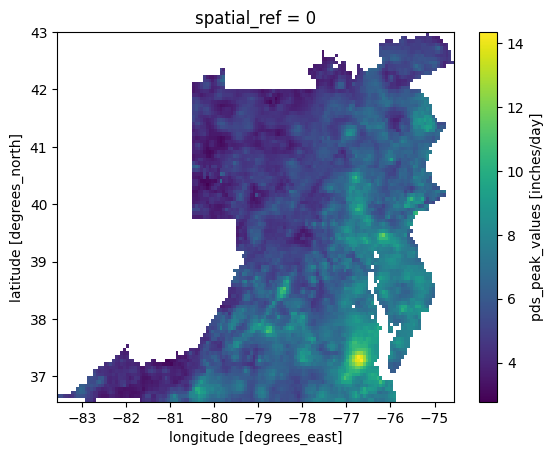

In [ ]:
r_hist.sel(return_periods = 5, n_b = 0).plot()

In [ ]:
lat, lon = data_io.get_valid_grid_point(input_data)
check = input_data.sel(x=lon, y=lat, method='nearest')

GEV parameters: shape=-0.4602, loc=2.0232, scale=0.2448


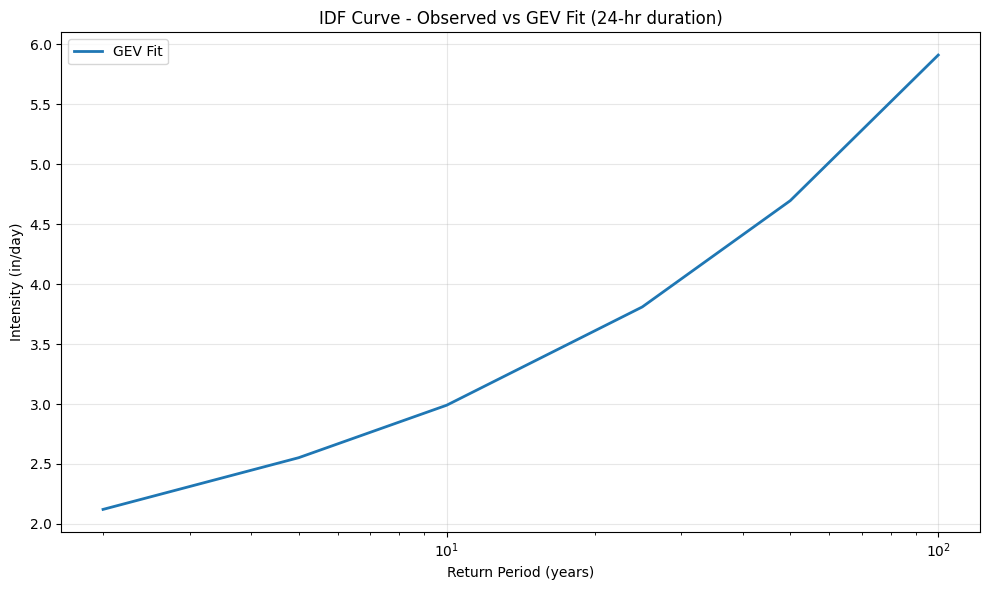

In [ ]:
from modules import statistics
return_periods = [2, 5, 10, 25, 50, 100]
# Fit GEV to the intensities
gev_params = statistics.fit_gev(check.values)
print(f"GEV parameters: shape={gev_params[0]:.4f}, loc={gev_params[1]:.4f}, scale={gev_params[2]:.4f}")

# Calculate fitted values
fitted_intensities = np.array([statistics.gev_return_period(gev_params, rp) for rp in return_periods])

# Plot observed vs fitted
fig, ax = plt.subplots(figsize=(10, 6))
#ax.plot(return_periods, check.values, 'o', label='Observed', markersize=8)
ax.plot(return_periods, fitted_intensities, '-', label='GEV Fit', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Intensity (in/day)')
ax.set_title('IDF Curve - Observed vs GEV Fit (24-hr duration)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/AdjFactors"
ver = 'LOCA2'
model = 'ACCESS-ESM1-5'
adjFactors_check = xr.open_dataset(f'{SAVE_DIR}/adj_factors_{ver}_nb100_{model}.zarr', consolidated=False)

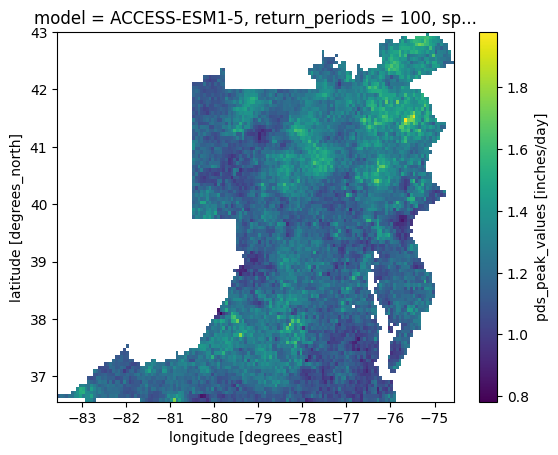

In [ ]:
adjFactors_check.sel(model = 'ACCESS-ESM1-5',
                     scenario = 'ssp585',
                     time_period = '2050-2100',
                     return_periods = 100).median(dim = 'n_b')['pds_peak_values'].plot()

Annual Maximum Series (AMS):
  Shape: (51, 103, 144)
  Years: 51
  Range: 0.61 to 14.18 inches/day

Annual Totals:
  Shape: (51, 103, 144)
  Range: 0.00 to 107.83 inches/year


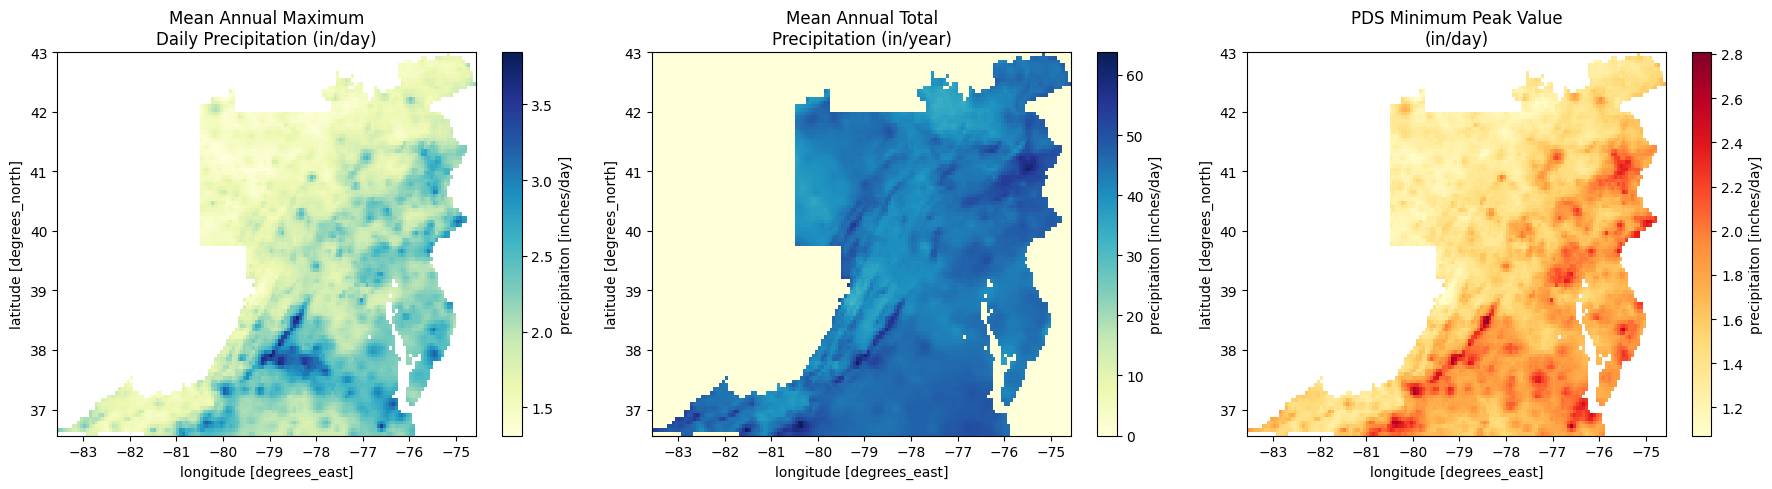

In [ ]:
#result = result.sel(ensemble = 1)
# Annual Maximum Series (AMS)
ams = result['ams']
print("Annual Maximum Series (AMS):")
print(f"  Shape: {ams.shape}")
print(f"  Years: {len(ams.year)}")
print(f"  Range: {ams.min().values:.2f} to {ams.max().values:.2f} inches/day")

# Annual Totals
annual_totals = result['annual_total']
print("\nAnnual Totals:")
print(f"  Shape: {annual_totals.shape}")
print(f"  Range: {annual_totals.min().values:.2f} to {annual_totals.max().values:.2f} inches/year")

# PDS (if computed)
if 'pds_n_peaks' in result:
    n_peaks = result['pds_n_peaks']
    threshold = result['pds_threshold']
    print("\nPartial Duration Series (PDS):")
    print(f"  Mean peaks per grid cell: {n_peaks.mean().values:.1f}")
    print(f"  Threshold range: {threshold.min().values:.2f} to {threshold.max().values:.2f} inches/day")

# Plot mean AMS across all years
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean AMS
ams.mean(dim='year').plot(ax=axes[0], cmap='YlGnBu')
axes[0].set_title('Mean Annual Maximum\nDaily Precipitation (in/day)')

# Mean Annual Total
annual_totals.mean(dim='year').plot(ax=axes[1], cmap='YlGnBu')
axes[1].set_title('Mean Annual Total\nPrecipitation (in/year)')

# PDS threshold (if available)
if 'pds_min_peak' in result:
    result['pds_min_peak'].plot(ax=axes[2], cmap='YlOrRd')
    axes[2].set_title('PDS Minimum Peak Value\n(in/day)')
else:
    # Plot number of peaks instead
    axes[2].text(0.5, 0.5, 'PDS not computed', ha='center', va='center')
    axes[2].axis('off')

plt.tight_layout()
plt.show()